In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pathlib

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Point to train and test folders separately
train_dir = pathlib.Path("/content/drive/MyDrive/intel_dataset/seg_train/seg_train")
test_dir  = pathlib.Path("/content/drive/MyDrive/intel_dataset/seg_test/seg_test")

CLASS_NAMES = sorted([item.name for item in train_dir.glob('*') if item.is_dir()])
image_count = len(list(train_dir.glob('*/*.jpg')))

print(f"✅ Classes found: {CLASS_NAMES}")
print(f"✅ Total training images: {image_count}")

Mounted at /content/drive
✅ Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
✅ Total training images: 14034


In [20]:
IMG_SIZE   = (64, 64)   # ← reduced from 128x128 to save RAM
BATCH_SIZE = 16         # ← reduced from 32 to save RAM
SEED       = 42

# ── Load training data ────────────────────────────────────────────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# ── Augmentation ──────────────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")  # ← fewer augmentations to save RAM

# ── Normalize + augment training ──────────────────────────────────────────────
train_ds = (train_ds
            .map(lambda x, y: (x / 255.0, y),
                 num_parallel_calls=2)          # ← limited parallel calls
            .map(lambda x, y: (augment(x, training=True), y),
                 num_parallel_calls=2)
            .shuffle(500)                       # ← reduced shuffle buffer
            .prefetch(1))                       # ← prefetch only 1 batch

# ── Normalize validation only ─────────────────────────────────────────────────
val_ds = (val_ds
          .map(lambda x, y: (x / 255.0, y),
               num_parallel_calls=2)
          .prefetch(1))

print("✅ Preprocessing complete!")

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
✅ Preprocessing complete!


In [21]:
def build_cnn(input_shape=(64, 64, 3), num_classes=6):
    inputs = tf.keras.Input(shape=input_shape)

    # ── Block 1 ───────────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3,3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2 ───────────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3 ───────────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    # ── Classifier ────────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="Intel_CNN")

model = build_cnn()
model.summary()

Model: "Intel_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 324,390 (1.24 MB)

 Trainable params: 322,982 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=7, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/intel_dataset/best_model.keras",
        save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/30
702/702 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4271 - loss: 1.5937
Epoch 1: val_loss improved from inf to 1.76774, saving model to /content/drive/MyDrive/intel_dataset/best_model.keras
702/702 ━━━━━━━━━━━━━━━━━━━━ 88s 47ms/step - accuracy: 0.4272 - loss: 1.5934 - val_accuracy: 0.3852 - val_loss: 1.7677 - learning_rate: 0.0010
Epoch 2/30
700/702 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5996 - loss: 1.0426
Epoch 2: val_loss improved from 1.76774 to 0.81226, saving model to /content/drive/MyDrive/intel_dataset/best_model.keras
702/702 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - accuracy: 0.5997 - loss: 1.0424 - val_accuracy: 0.6935 - val_loss: 0.8123 - learning_rate: 0.0010
Epoch 3/30
698/702 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6638 - loss: 0.9034
Epoch 3: val_loss did not improve from 0.81226
702/702 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.6639 - loss: 0.9032 - val_accuracy: 0.6796 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 4/30
699/702 ━━━━

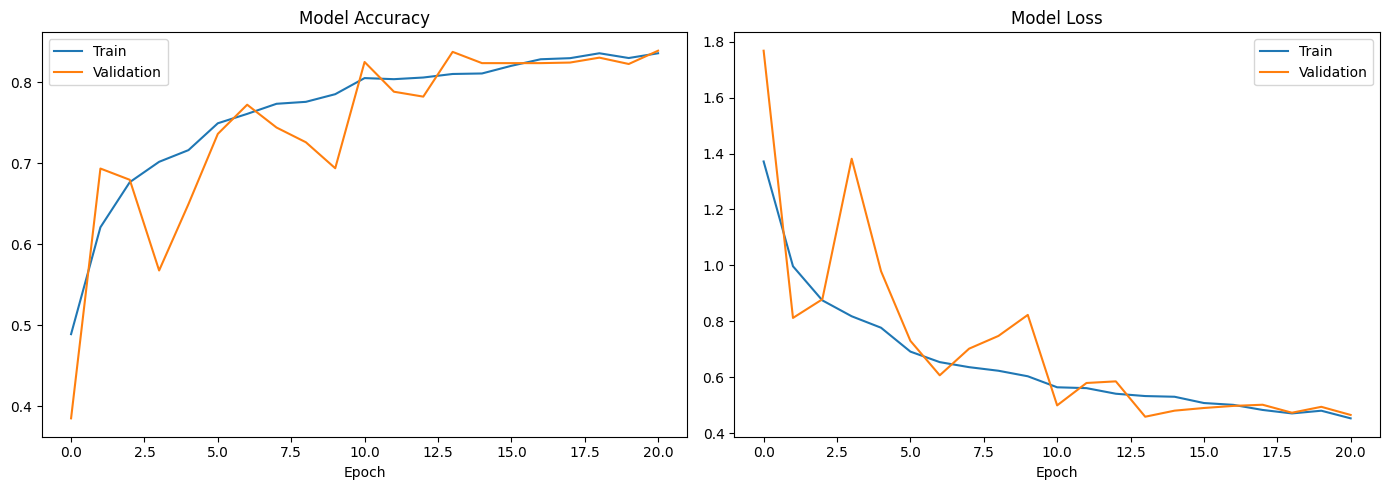


✅ Final Validation Accuracy: 83.75%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()

loss, acc = model.evaluate(val_ds, verbose=0)
print(f"\n✅ Final Validation Accuracy: {acc*100:.2f}%")